In [129]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [130]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.csv',sep=';',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\mym\1HZL.xlsx')
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 27029 entries, 0 to 27028
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  27029 non-null  str  
 1   Message  27029 non-null  str  
 2   Status   27029 non-null  str  
dtypes: str(3)
memory usage: 633.6 KB


In [131]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('0x252521')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [132]:
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
date_fs02_dec_value=[]
fs01_raw_data=[]
fs02_raw_data=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs01_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs01_aux.find('3E01')
    if ((aux>47) & (aux<49)):
        fs01=(e0x_aux[48:66])
        #print(fs01,e0x.iloc[i,2])
        if len(fs01)>17:
            msb=fs01[10:12]
            lsb=fs01[8:10]
            measure=msb+lsb
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs01=i
            fs01_raw_data.append(e0x_aux)
            
#print(i, raw_data.iloc[i,0] )

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs02_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs02_aux.find('3E02')    
    if ((aux>47) & (aux<49)):
        fs02=e0x_aux[48:66]
        #print(fs02,aux)
        if len(fs02)>17:
            msb=fs02[10:12]
            lsb=fs02[8:10]
            measure=msb+lsb
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs02=i
            fs02_raw_data.append(e0x_aux)
            
        #print(fs01_cad)   

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)
#print('El Ncode en decimal es:')
values_dates_fs01['value']=fs01_dec_value
values_dates_fs01['date']=date_fs01_dec_value
values_dates_fs01['raw data']=fs01_raw_data
values_dates_fs02['value']=fs02_dec_value
values_dates_fs02['date']=date_fs02_dec_value
values_dates_fs02['raw data']=fs02_raw_data

values_dates_fs01_ordered=values_dates_fs01.sort_values('date',ascending=True)
values_dates_fs02_ordered=values_dates_fs02.sort_values('date',ascending=True)

values_dates_fs01_ordered.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\macu\Exportfs01.csv')
print("Last fuel report fs01: ",e0x.iloc[last_index_fs01,0],"Last fuel report fs02: ",e0x.iloc[last_index_fs02,0])

Last fuel report fs01:  2026-09-04 13:08:03.728 Last fuel report fs02:  2026-09-04 13:08:03.169


In [133]:
values_dates_fs01.info()
values_dates_fs02.info()

<class 'pandas.DataFrame'>
RangeIndex: 10819 entries, 0 to 10818
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     10819 non-null  int64
 1   date      10819 non-null  str  
 2   raw data  10819 non-null  str  
dtypes: int64(1), str(2)
memory usage: 253.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 4447 entries, 0 to 4446
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     4447 non-null   int64
 1   date      4447 non-null   str  
 2   raw data  4447 non-null   str  
dtypes: int64(1), str(2)
memory usage: 104.4 KB


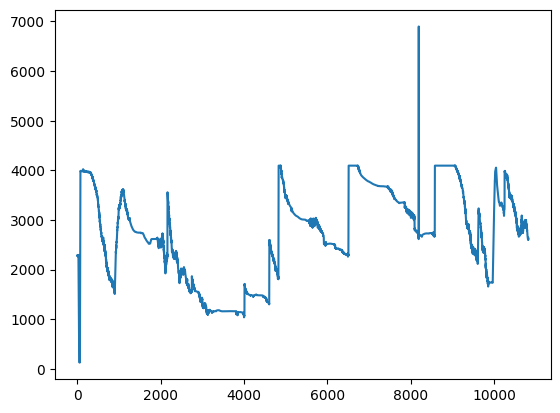

In [134]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,values_dates_fs01_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

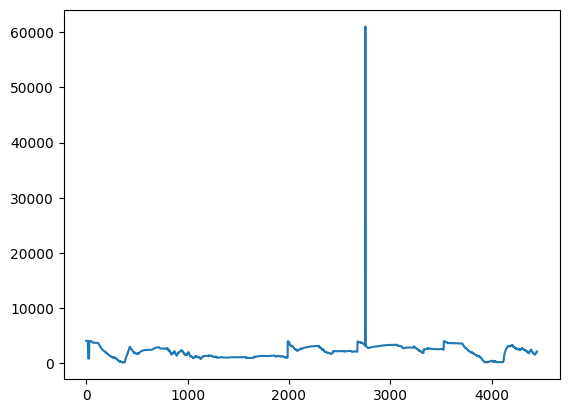

In [135]:
plt.plot(fs02_x_values,values_dates_fs02_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

In [136]:
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,0])>4095:
        print(i,values_dates_fs01_ordered.iloc[i,2],'->',values_dates_fs01_ordered.iloc[1,2][32:44],values_dates_fs01_ordered.iloc[i,0])

8190 0x25252100242CF5086948706020102626083115201801013E01071FF31A3FFBFB0AEFAF3B -> 260819150030 6899


In [137]:
values_dates_fs01_ordered.info()

<class 'pandas.DataFrame'>
Index: 10819 entries, 0 to 10818
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     10819 non-null  int64
 1   date      10819 non-null  str  
 2   raw data  10819 non-null  str  
dtypes: int64(1), str(2)
memory usage: 338.1 KB


In [138]:
for i in range(0,values_dates_fs01_ordered.shape[0]):
    print(i,values_dates_fs01_ordered.iloc[i,2],'->',values_dates_fs01_ordered.iloc[i,2][32:44],values_dates_fs01_ordered.iloc[i,0])

0 0x25252100200001086948706020102626081914584500013E010716EC08CF8E5C -> 260819145845 2284
1 0x25252100200002086948706020102626081915003000013E010716EC08CB8E67 -> 260819150030 2284
2 0x25252100200004086948706020102626081915021500013E010716EC08CA8EA3 -> 260819150215 2284
3 0x25252100200005086948706020102626081915040000013E010716EC08C98EF6 -> 260819150400 2284
4 0x25252100200006086948706020102626081915054500013E010716EC08CE8E98 -> 260819150545 2284
5 0x25252100200008086948706020102626081915073000013E010716EC08C38E11 -> 260819150730 2284
6 0x25252100200009086948706020102626081915091500013E010716EC08C38E11 -> 260819150915 2284
7 0x2525210020000B086948706020102626081915110000013E010716EC08C28ED5 -> 260819151100 2284
8 0x2525210020000C086948706020102626081915124500013E010717DB08B38D46 -> 260819151245 2267
9 0x2525210020000E086948706020102626081915143000013E010717F108138F7F -> 260819151430 2289
10 0x2525210020000F086948706020102626081915161500013E010717F708798FCB -> 260819151615 2295
11 0x2525

In [139]:
for i in range(0,values_dates_fs02_ordered.shape[0]):
    print(values_dates_fs02_ordered.iloc[i,2],'->',values_dates_fs02_ordered.iloc[i,2][32:44],values_dates_fs02_ordered.iloc[i,0])

0x25252100200003086948706020102626081915013100013E020715FF0FFFFF14 -> 260819150131 4095
0x25252100200007086948706020102626081915054600013E020716FF0FFFFF5A -> 260819150546 4095
0x2525210020000A086948706020102626081915100100013E020716FF0FFFFF5A -> 260819151001 4095
0x2525210020000D086948706020102626081915141600013E020716FF0FFFFF5A -> 260819151416 4095
0x25252100200011086948706020102626081915183100013E020716FF0FFFFF5A -> 260819151831 4095
0x25252100200014086948706020102626081915224600013E020716FF0FFFFF5A -> 260819152246 4095
0x25252100200018086948706020102626081915270100013E020716FF0FFFFF5A -> 260819152701 4095
0x2525210020001B086948706020102626081915311600013E020716FF0FFFFF5A -> 260819153116 4095
0x2525210020001F086948706020102626081915353100013E020716FF0FFFFF5A -> 260819153531 4095
0x25252100200022086948706020102626081915394600013E020716FF0FFFFF5A -> 260819153946 4095
0x25252100200025086948706020102626081915440100013E020716FF0FFFFF5A -> 260819154401 4095
0x252521002000290869487060201026

In [140]:
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>260819155115:
        print(i,values_dates_fs01_ordered.iloc[i,2],'->',values_dates_fs01_ordered.iloc[i,2][32:44],values_dates_fs01_ordered.iloc[i,0])

31 0x2525210020002D086948706020102626081915530000013E010717EC05CF5ED6 -> 260819155300 1516
32 0x2525210020002E086948706020102626081915544500013E01071790050B5960 -> 260819155445 1424
33 0x2525210020002F086948706020102626081915563000013E01071706056250FC -> 260819155630 1286
34 0x25252100200031086948706020102626081915581500013E0107177204214721 -> 260819155815 1138
35 0x25252100200032086948706020102626081916000000013E010717DB03B53D1F -> 260819160000 987
36 0x25252100200034086948706020102626081916014500013E0107174003073465 -> 260819160145 832
37 0x25252100200035086948706020102626081916033000013E010717BB02B02B9B -> 260819160330 699
38 0x25252100200036086948706020102626081916051500013E0107175602622599 -> 260819160515 598
39 0x25252100200038086948706020102626081916070000013E010717C701771C22 -> 260819160700 455
40 0x25252100200039086948706020102626081916084500013E0107174701701457 -> 260819160845 327
41 0x2525210020003B086948706020102626081916103000013E0107178E00ED0822 -> 260819161030 142
42 0x2

In [141]:
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>260819155115:
        print(i,values_dates_fs02_ordered.iloc[i,2],'->',values_dates_fs02_ordered.iloc[i,2][32:44],values_dates_fs02_ordered.iloc[i,0])

12 0x2525210020002C086948706020102626081915523100013E020716FF0FFFFF5A -> 260819155231 4095
13 0x25252100200030086948706020102626081915564600013E020716FF0FFFFF5A -> 260819155646 4095
14 0x25252100200033086948706020102626081916010200013E020716FF0FFFFF5A -> 260819160102 4095
15 0x25252100200037086948706020102626081916051700013E020716FF0FFFFF5A -> 260819160517 4095
16 0x2525210020003A086948706020102626081916093200013E020716FF0FFFFF5A -> 260819160932 4095
17 0x2525210020003D086948706020102626081916134700013E020717410E13E43D -> 260819161347 3649
18 0x25252100200041086948706020102626081916180200013E020717480A80A4E0 -> 260819161802 2632
19 0x25252100200044086948706020102626081916221700013E020717A3073C7A2A -> 260819162217 1955
20 0x25252100200048086948706020102626081916263200013E02071721051852A0 -> 260819162632 1313
21 0x2525210020004B086948706020102626081916304700013E02071777037A3731 -> 260819163047 887
22 0x2525210020004F086948706020102626081916350200013E02071779039837C0 -> 260819163502 889
2

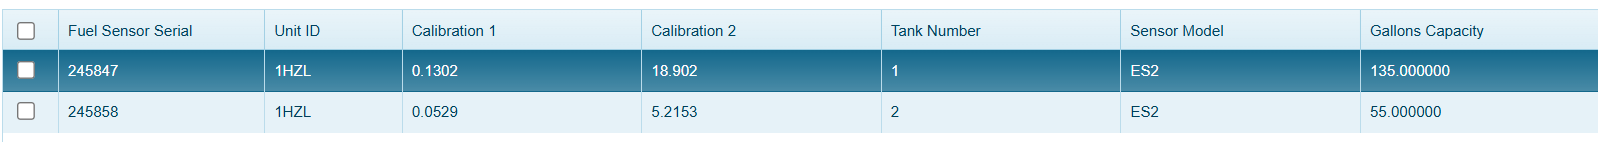

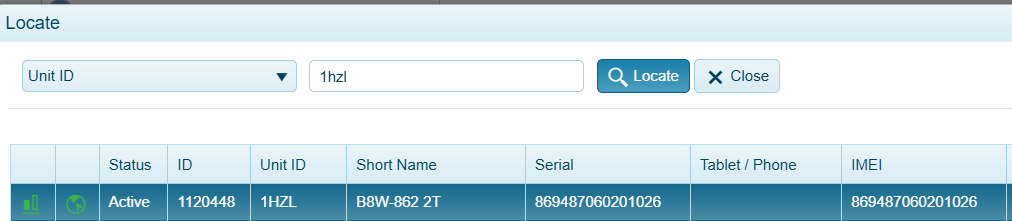

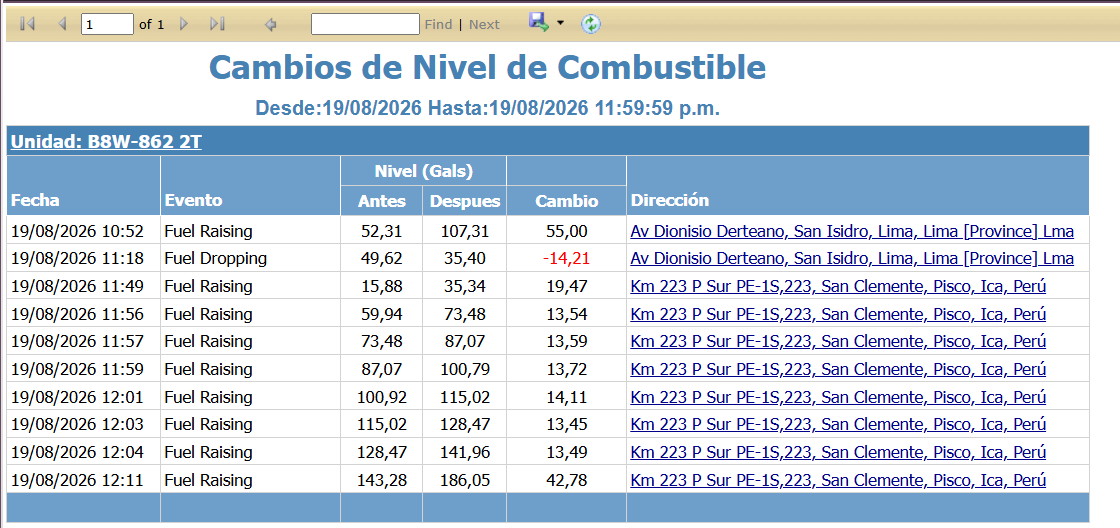

In [142]:
#Tank of 135gallons 
"""
62 0x25252100200058086948706020102626081916471600013E01071820010F125D -> 260819164716 288
63 0x2525210020005A086948706020102626081916490100013E01071856036635FB -> 260819164901 854
64 0x2525210020005B086948706020102626081916504600013E01071828048842EE -> 260819165046 1064
65 0x2525210020005D086948706020102626081916523100013E01071821051A5219 -> 260819165231 1313
66 0x2525210020005E086948706020102626081916541600013E01071821061E6278 -> 260819165416 1569
67 0x2525210020005F086948706020102626081916560100013E010718AB07BF7A64 -> 260819165601 1963
68 0x25252100200061086948706020102626081916574600013E010718360963938C -> 260819165746 2358
69 0x25252100200062086948706020102626081916593100013E010718C50A52AC87 -> 260819165931 2757
70 0x25252100200064086948706020102626081917011600013E0107185F0CF0C52A -> 260819170116 3167
71 0x25252100200065086948706020102626081917030100013E010718E60D64DEC6 -> 260819170301 3558
72 0x25252100200066086948706020102626081917044600013E0107186E0FE1F67D -> 260819170446 3950
73 0x25252100200068086948706020102626081917063100013E0107188E0FEFF8F7 -> 260819170631 3982
74 0x25252100200069086948706020102626081917092100013E0107178B0FBCF83B -> 260819170921 3979
75 0x2525210020006A086948706020102626081917110600013E0107178B0FBCF83B -> 260819171106 3979
76 0x2525210020006C086948706020102626081917125100013E010717960F6EF909 -> 260819171251 3990
"""
x=[]
y=[]
for i in range(0,2):
    x.append(int(input("Enter the initial ncode for prediction: ")))

for i in range(0,2):
    y.append(0.1302*x[i]-18.902)
print("Differences:",y[1]/3.785412,'-',y[0]/3.785412,':',y[1]/3.785412-y[0]/3.785412,'gallons')

Differences: 132.24346517631372 - 4.912437536521785 : 127.33102763979194 gallons


In [143]:
#Tank of 55gallons
"""
17 0x2525210020003D086948706020102626081916134700013E020717410E13E43D -> 260819161347 3649
18 0x25252100200041086948706020102626081916180200013E020717480A80A4E0 -> 260819161802 2632
"""
x=[]
y=[]
for i in range(0,2):
    x.append(int(input("Enter the initial ncode for prediction: ")))

for i in range(0,2):
    y.append(0.0529*x[i]-5.2153)
print("Differences:",y[1]/3.785412,'-',y[0]/3.785412,':',y[1]/3.785412-y[0]/3.785412,'gallons')

Differences: 35.403676006733214 - 49.61594669219625 : -14.21227068546304 gallons


Analysis 2:

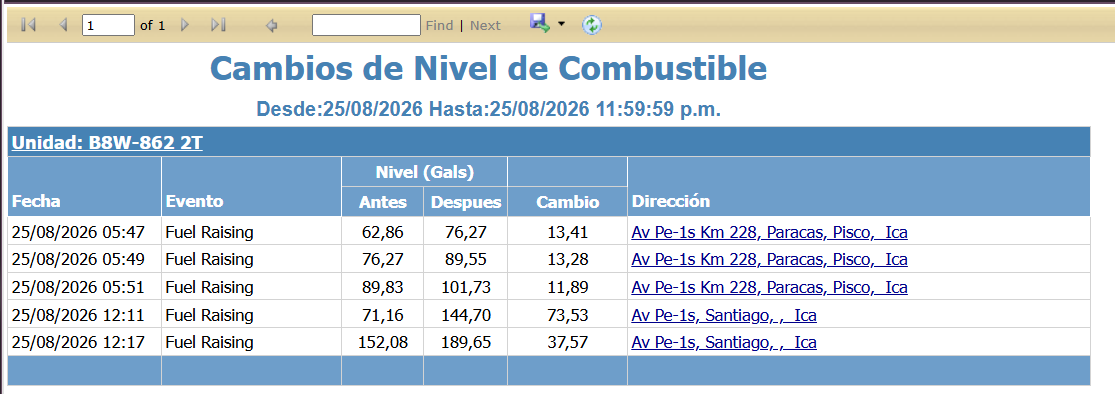

In [144]:
#Tank of 135gallons 
#4825 0x25252100201A72086948706020102626082517110400013E0107266F0FF8F68A -> 260825171104 3951
#4826 0x25252100201A73086948706020102626082517124900013E010724FF0FFFFF1A -> 260825171249 4095
x=[]
y=[]
for i in range(0,2):
    x.append(int(input("Enter the initial ncode for prediction: ")))

for i in range(0,2):
    y.append(0.1302*x[i]-18.902)
print("Differences:",y[1]/3.785412,'-',y[0]/3.785412,':',y[1]/3.785412-y[0]/3.785412,'gallons')

Differences: 135.8549610980258 - 130.90205240539208 : 4.952908692633713 gallons


In [145]:
#Tank of 55gallons
"""
1985 0x25252100201A6D086948706020102626082517043301013E02072E080482409A -> 260825170433 1032
1986 0x25252100201A70086948706020102626082517084800013E02072A3E04EE4331 -> 260825170848 1086
1987 0x25252100201A74086948706020102626082517130300013E0207252905985294 -> 260825171303 1321
1988 0x25252100201A77086948706020102626082517171800013E020721A90F92FAB2 -> 260825171718 4009
1989 0x25252100201A7A086948706020102626082517213300013E02071FA80F82FAF7 -> 260825172133 4008
1990 0x25252100201A7E086948706020102626082517254800013E02071FA90F96FAAF -> 260825172548 4009
"""
x=[]
y=[]
for i in range(0,2):
    x.append(int(input("Enter the initial ncode for prediction: ")))

for i in range(0,2):
    y.append(0.0529*x[i]-5.2153)
print("Differences:",y[1]/3.785412,'-',y[0]/3.785412,':',y[1]/3.785412-y[0]/3.785412,'gallons')

Differences: 54.64683897023626 - 13.044154770999828 : 41.602684199236435 gallons
